In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import openpyxl as px

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
e1 = pd.read_csv(r"/Users/alejandrabenavidessanclemente/Desktop/ProyectoGradoGEB/datos_procesados.csv")

In [5]:
nulos = e1.isnull().sum()
print(nulos)

duplicados = e1.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

ORIG_STD_VOLUME     0
STD_VOLUME          0
ORIG_TEMPERATURE    0
TEMPERATURE         0
PRESSURE            0
ORIG_PRESSURE       0
ORIG_RAW_VOLUME     0
RAW_VOLUME          0
EFFECTIVE_DATE      0
empresa_EICH101     0
empresa_EICH102     0
empresa_EICH104     0
dtype: int64
Número de filas duplicadas: 0


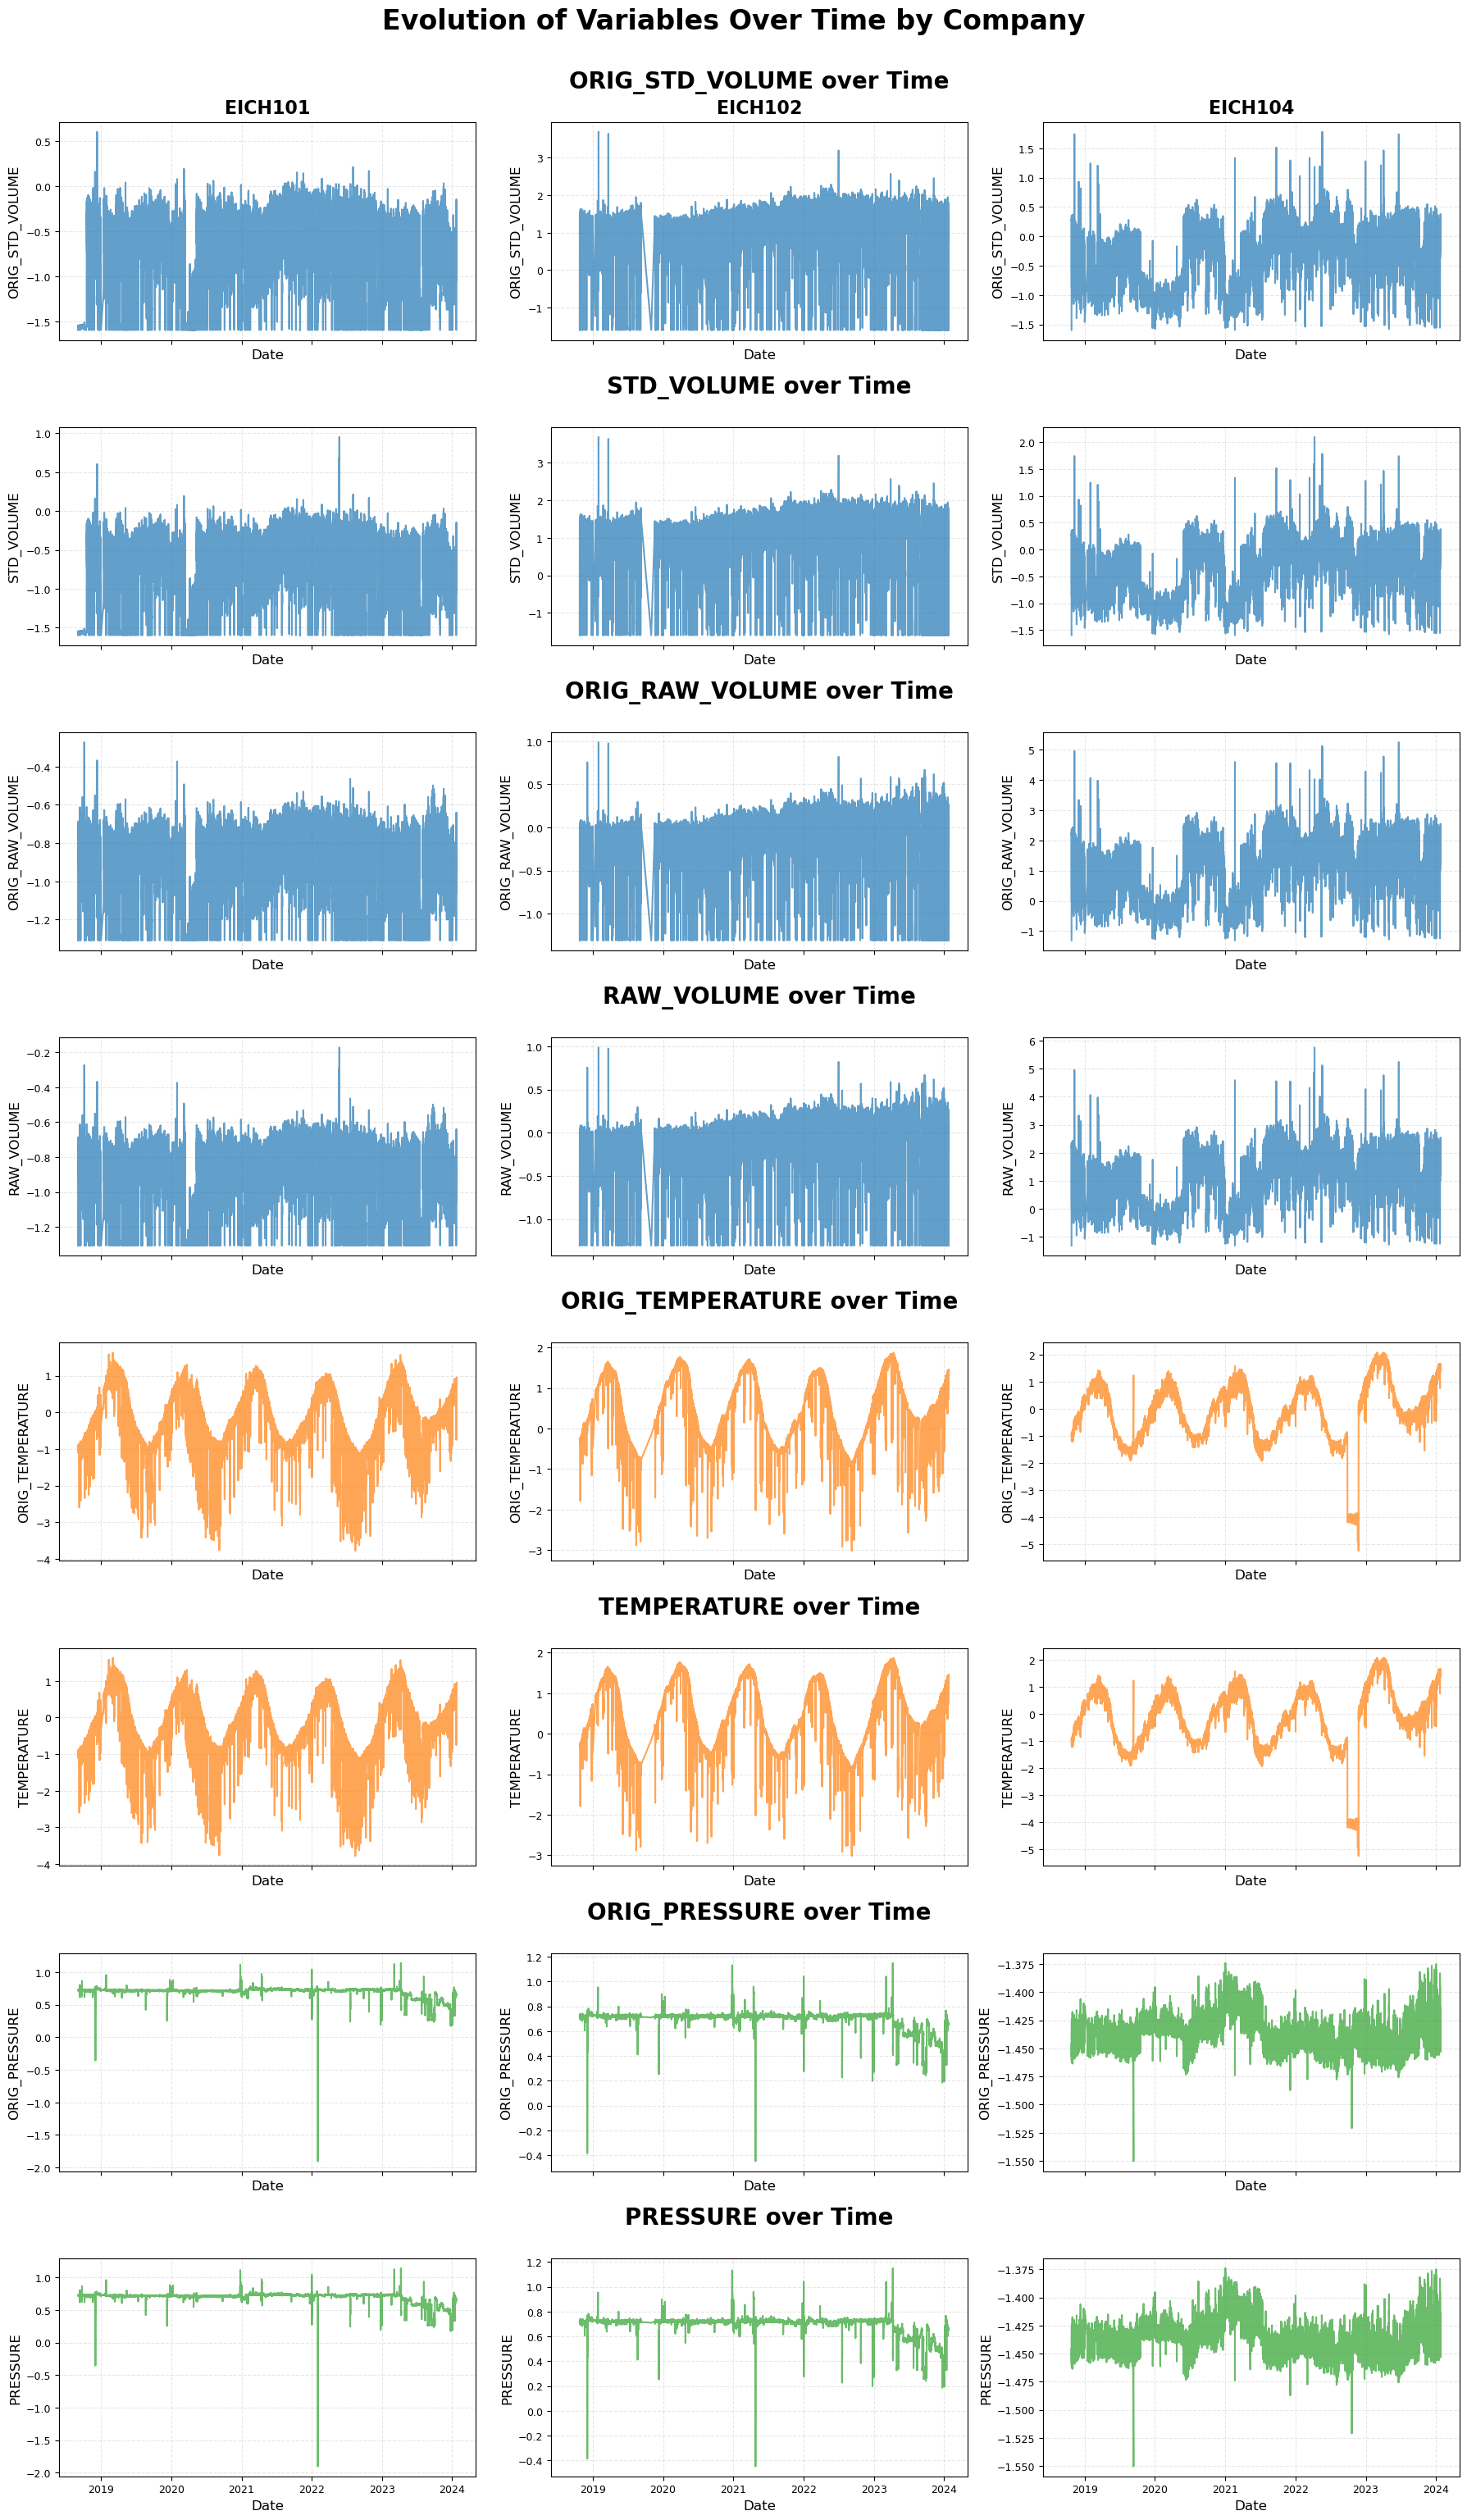

In [45]:
# Crear columna 'COMPANY' a partir del One-Hot Encoding
def identify_company(row):
    for col in ['empresa_EICH101', 'empresa_EICH102', 'empresa_EICH104']:
        if row[col] == 1:
            return col.replace('empresa_', '')
    return 'Unknown'

e1['COMPANY'] = e1.apply(identify_company, axis=1)

# Convertir fechas
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])

# Variables
variable_units = {
    'ORIG_STD_VOLUME',
    'STD_VOLUME',
    'ORIG_RAW_VOLUME',
    'RAW_VOLUME',
    'ORIG_TEMPERATURE',
    'TEMPERATURE',
    'ORIG_PRESSURE',
    'PRESSURE'
}

# Colores por categoría
category_colors = {
    'Volume': '#1f77b4',
    'Temperature': '#ff7f0e',
    'Pressure': '#2ca02c'
}

# Categorías
volume_vars = ['ORIG_STD_VOLUME', 'STD_VOLUME', 'ORIG_RAW_VOLUME', 'RAW_VOLUME']
temperature_vars = ['ORIG_TEMPERATURE', 'TEMPERATURE']
pressure_vars = ['ORIG_PRESSURE', 'PRESSURE']
variables = volume_vars + temperature_vars + pressure_vars

# Empresas
companies = e1['COMPANY'].unique()

# Crear figura
fig, axs = plt.subplots(len(variables), len(companies), figsize=(18, 4 * len(variables)), sharex=True)

# Asegurar que axs sea 2D
if len(companies) == 1:
    axs = axs.reshape(-1, 1)

# Graficar
for row_idx, var in enumerate(variables):
    if var in volume_vars:
        color = category_colors['Volume']
    elif var in temperature_vars:
        color = category_colors['Temperature']
    else:
        color = category_colors['Pressure']
    
    middle_col = len(companies) // 2  # Columna central para título de variable

    for col_idx, company in enumerate(companies):
        ax = axs[row_idx][col_idx]
        df_company = e1[e1['COMPANY'] == company]
        
        ax.plot(df_company['EFFECTIVE_DATE'], df_company[var], color=color, alpha=0.7)
        
        ax.set_ylabel(f"{var}", fontsize=12)
        ax.set_xlabel("Date", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=9)
        
        # Mostrar nombre de la empresa solo en la primera fila como subtítulo discreto
        if row_idx == 0:
            ax.annotate(company, xy=(0.5, 1.02), xycoords='axes fraction',
                        ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Título de la variable centrado en la fila (solo en gráfico del medio)
    axs[row_idx][middle_col].set_title(f"{var} over Time", fontsize=20, fontweight='bold', pad=30)

# Ajustar diseño
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle("Evolution of Variables Over Time by Company", fontsize=24, fontweight='bold', y=0.989)
plt.subplots_adjust(hspace=0.4, wspace=0.18)
plt.show()

In [47]:
# Crear un nuevo DataFrame con los datos filtrados
e1_filtered_data = e1.copy()

# Eliminar los 3 valores más altos de ORIG_STD_VOLUME
top_values_volume = e1['ORIG_STD_VOLUME'].nlargest(3)
e1_filtered_data = e1_filtered_data[~e1_filtered_data['ORIG_STD_VOLUME'].isin(top_values_volume)]

# Eliminar los 3 valores más bajos de PRESSURE
smallest_values_pressure = e1['PRESSURE'].nsmallest(3)
e1_filtered_data = e1_filtered_data[~e1_filtered_data['PRESSURE'].isin(smallest_values_pressure)]

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


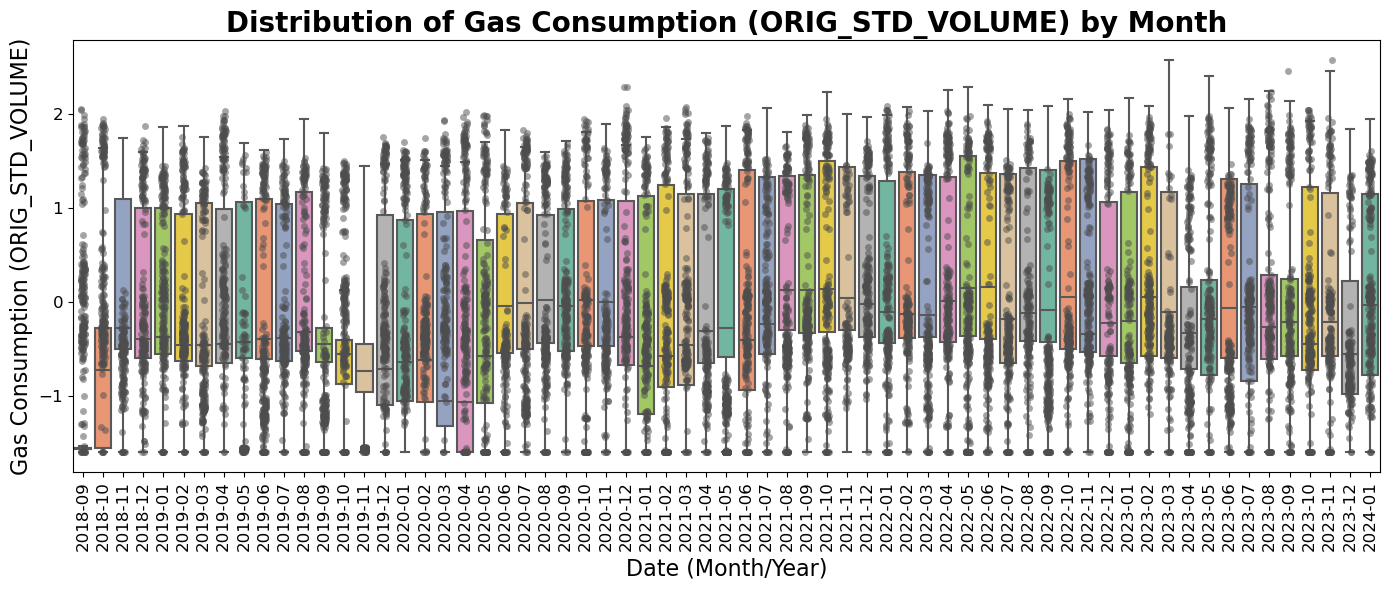

In [48]:
# Create a copy of the processed DataFrame
processed_e1_df = e1_filtered_data.copy()

# Convert the date to a Year-Month period for better grouping
processed_e1_df['YearMonth'] = processed_e1_df['EFFECTIVE_DATE'].dt.to_period("M")

# Configurar la figura
plt.figure(figsize=(14, 6))

# Create the boxplot for gas consumption
ax = sns.boxplot(
    data=processed_e1_df,
    x='YearMonth',
    y='ORIG_STD_VOLUME',
    palette='Set2',
    whis=np.inf  # Include all values (no whisker limits)
)

# Add a stripplot to show individual values
ax = sns.stripplot(
    data=processed_e1_df.sample(frac=0.1, random_state=42),  # Sample to avoid overplotting
    x='YearMonth',
    y='ORIG_STD_VOLUME',
    color='.3',
    alpha=0.5
)

# Set title and axis labels in English
plt.title('Distribution of Gas Consumption (ORIG_STD_VOLUME) by Month', fontsize=20, fontweight='bold')
plt.xlabel('Date (Month/Year)', fontsize=16)
plt.ylabel('Gas Consumption (ORIG_STD_VOLUME)', fontsize=16)

# Rotate X-axis tick labels vertically
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/alejandrabenavidessanclemente/anaconda3/lib/pytho

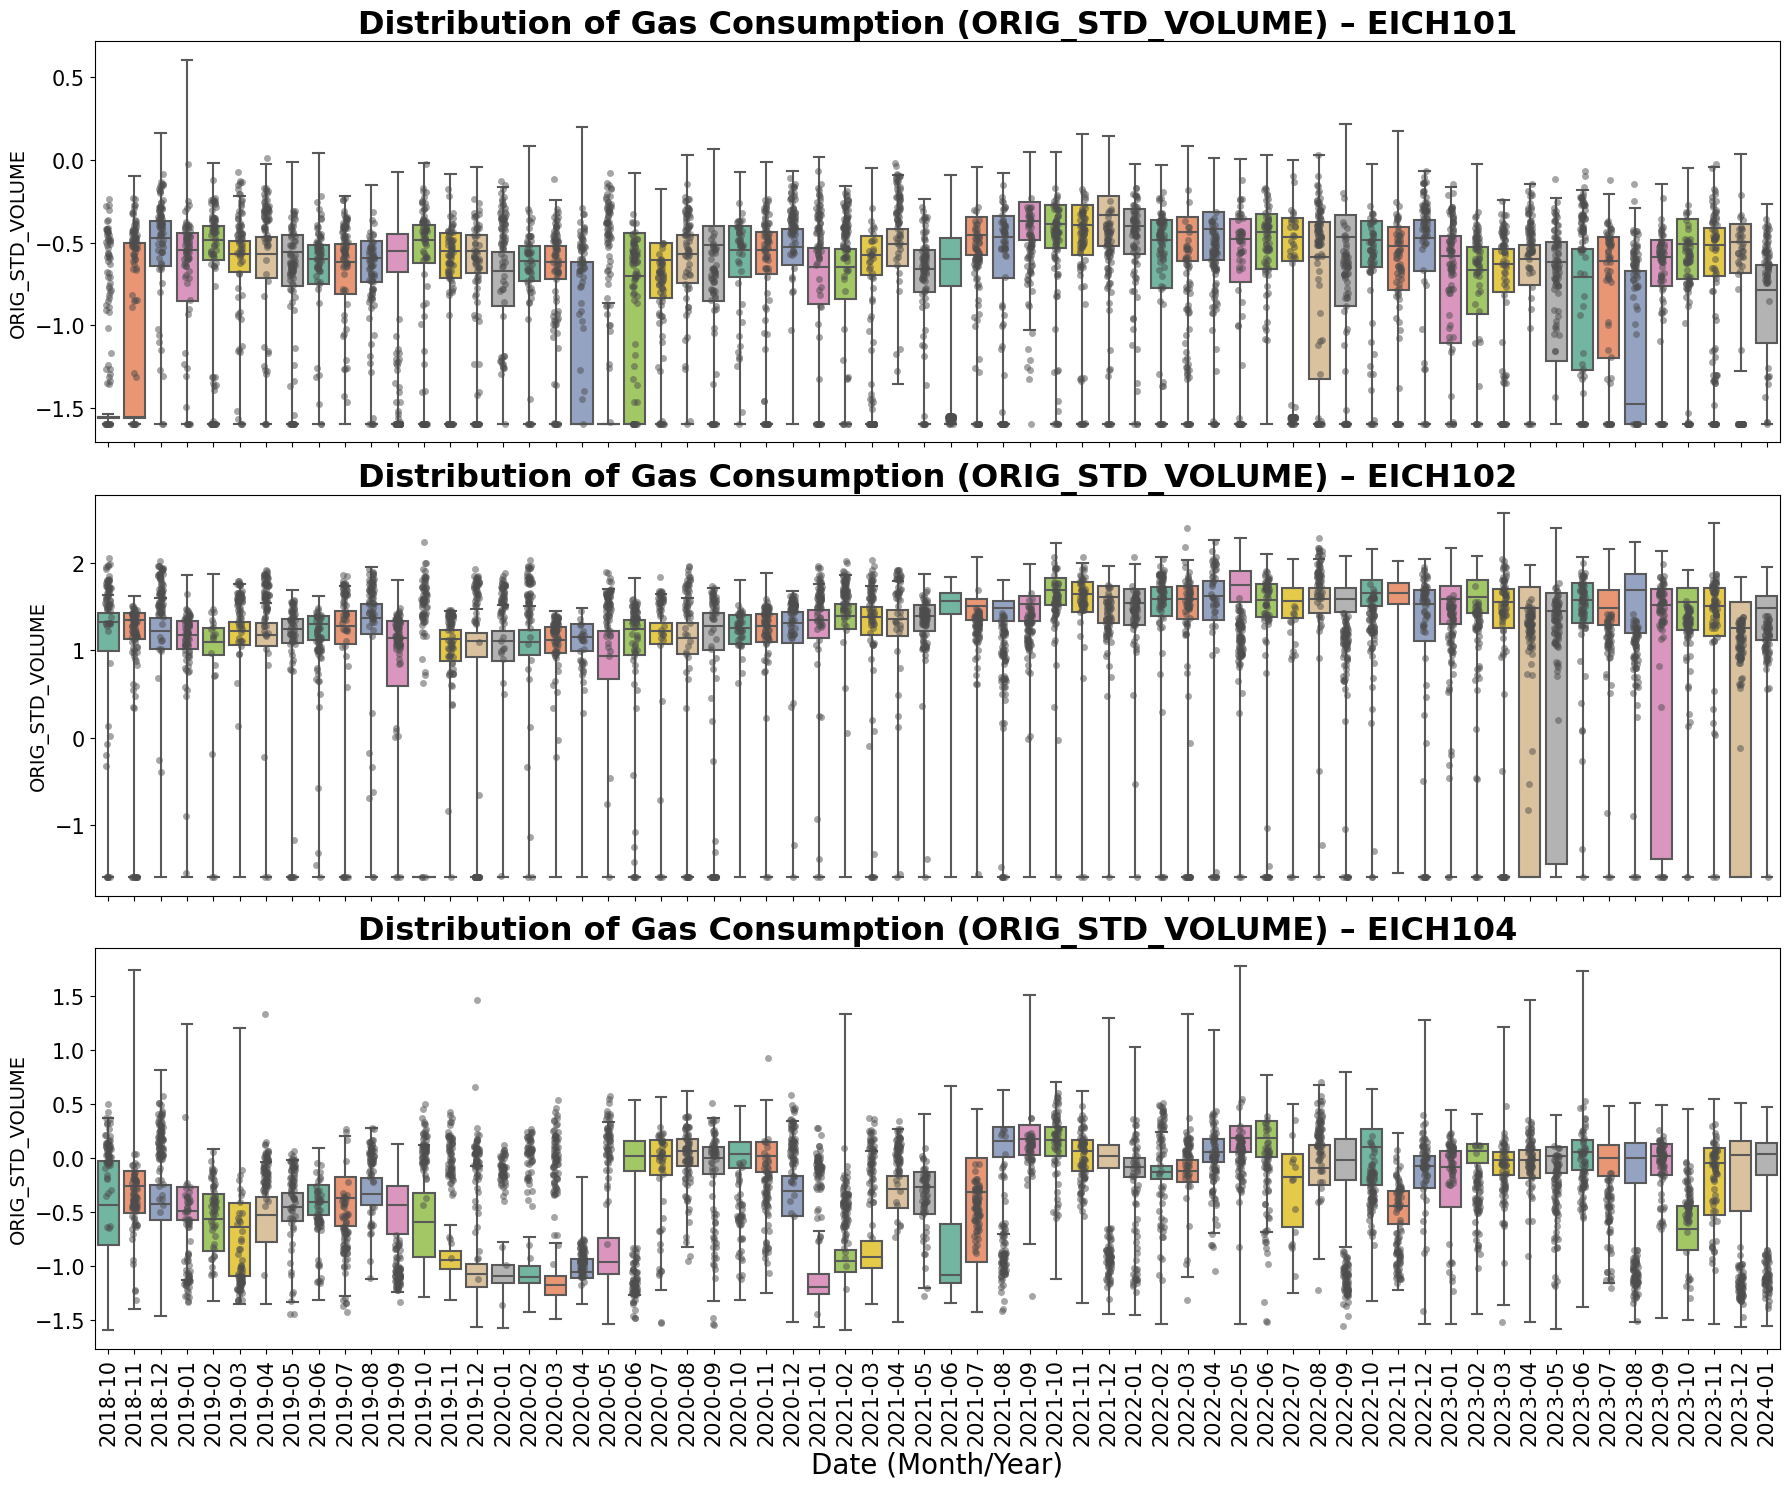

In [52]:
# Crear figura con 3 subplots (uno por empresa)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convertir EFFECTIVE_DATE a YearMonth si aún no lo has hecho
processed_e1_df['YearMonth'] = processed_e1_df['EFFECTIVE_DATE'].dt.to_period("M")

# Obtener lista de empresas
companies = processed_e1_df['COMPANY'].unique()

# Crear figura con 3 subplots verticales
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 15), sharex=True)

for i, company in enumerate(companies):
    df_company = processed_e1_df[processed_e1_df['COMPANY'] == company]

    ax = axes[i]  # Subplot correspondiente

    sns.boxplot(
        data=df_company,
        x='YearMonth',
        y='ORIG_STD_VOLUME',
        palette='Set2',
        whis=np.inf,
        ax=ax
    )

    sns.stripplot(
        data=df_company.sample(frac=0.1, random_state=42),
        x='YearMonth',
        y='ORIG_STD_VOLUME',
        color='.3',
        alpha=0.5,
        ax=ax
    )

    ax.set_title(f'Distribution of Gas Consumption (ORIG_STD_VOLUME) – {company}', fontsize=23, fontweight='bold')
    ax.set_ylabel('ORIG_STD_VOLUME', fontsize=14)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=15)
    ax.set_xlabel('')

# Ajustar etiquetas del eje x en el último subplot
axes[-1].set_xlabel('Date (Month/Year)', fontsize=20)
axes[-1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
